In [1]:
import numpy as np
import matplotlib.pyplot as plt
from collections.abc import Iterable

## sigle thread

In [2]:
def plot(data_list, title, labels):

    fig, ax = plt.subplots(figsize=[8, 8])

    boxes = []
    ticks = []

    for i in range(0,len(data_list)):
        boxes.append(data_list[i])
        ticks.append(labels[i])

    bplot = ax.boxplot(boxes, showfliers=False)
    # Etichette per gli assi
    ax.set_xticks(range(1,len(labels)+1),ticks)
    ax.set(ylabel = 'Microseconds')
    ax.set(title = title)

    for median in bplot['medians']:
        median.set_color('red')
    plt.figtext(0.78, 0.9, f"runs: {len(data_list[0])}\nn_elem: {n_elem}", fontsize=9, 
            bbox=dict(facecolor='white', edgecolor='black'))
    plt.show()

In [ ]:
# rimuovi .txt a mano altrimenti aggiunge dati a gia esistenti poi run $./single.sh nomepush/pop n_runs n_elem 

pop back

In [74]:
!./single.sh pop_back 50 1600

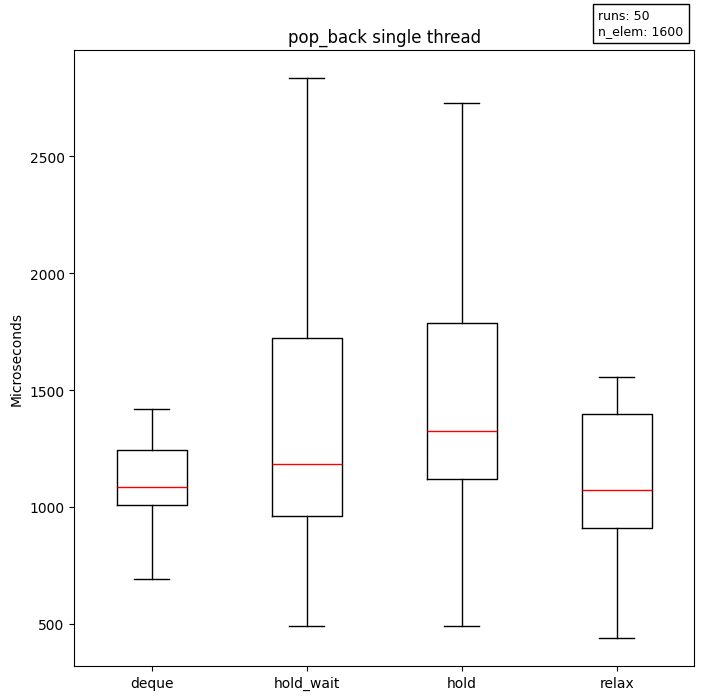

In [75]:
# dati test
nomi = ["deque", "hold_wait", "hold", "relax"]
dati_pop_back = []
for i in range(4):
    dati_pop_back.append(np.genfromtxt("test_"+nomi[i]+"_pop_back.txt",delimiter=',',dtype=int)[:-1])

n_elem = 1600

plot(dati_pop_back,"pop_back single thread", nomi)

pop front

In [72]:
!./single.sh pop_front 50 1600

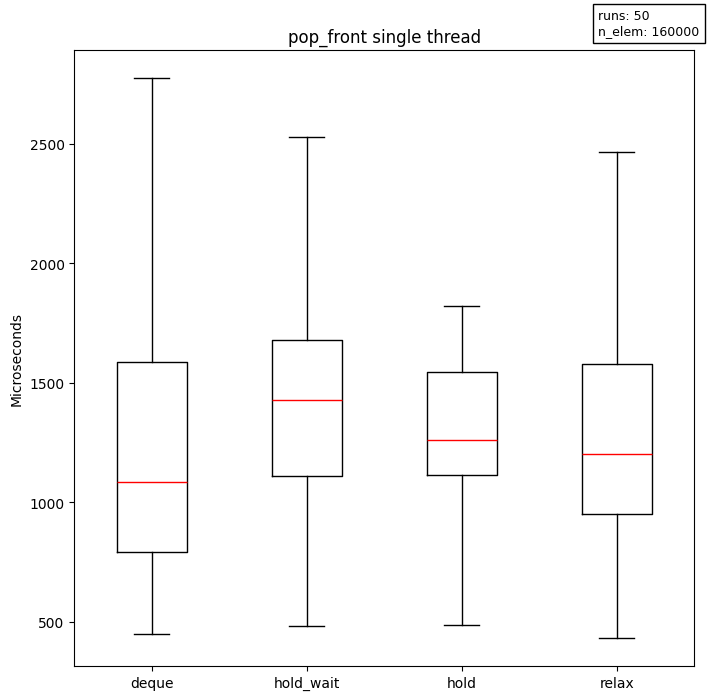

In [73]:
# pop_front
# dati test
nomi = ["deque", "hold_wait", "hold", "relax"]
dati_pop_back = []
for i in range(4):
    dati_pop_back.append(np.genfromtxt("test_"+nomi[i]+"_pop_front.txt",delimiter=',',dtype=int)[:-1])
    
n_elem = 160000

plot(dati_pop_back,"pop_front single thread", nomi)

push back

In [67]:
!./single.sh push_back 50 1600

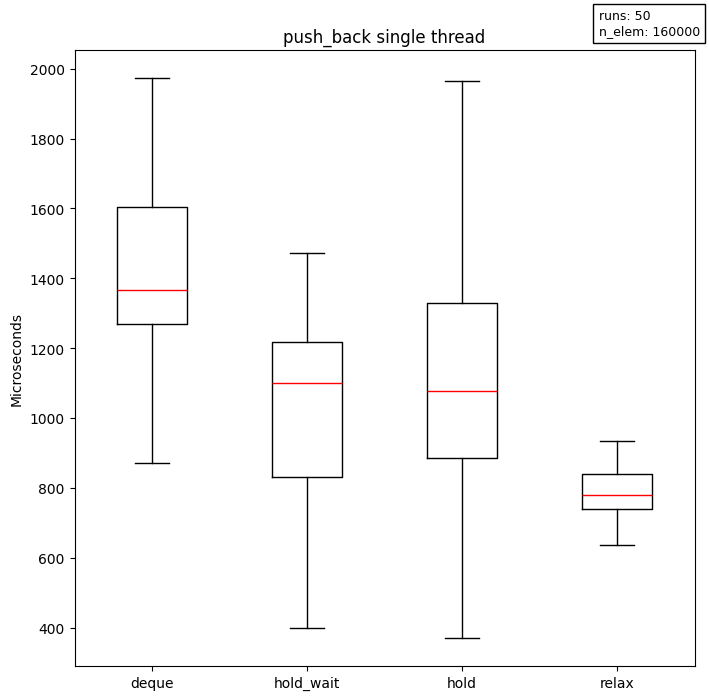

In [68]:
# push_back
# dati test
nomi = ["deque", "hold_wait", "hold", "relax"]
dati_push_back = []
for i in range(4):
    dati_push_back.append(np.genfromtxt("test_"+nomi[i]+"_push_back.txt",delimiter=',',dtype=int)[:-1])
    
n_elem = 160000

plot(dati_push_back,"push_back single thread", nomi)

push front

In [70]:
!./single.sh push_front 50 1600

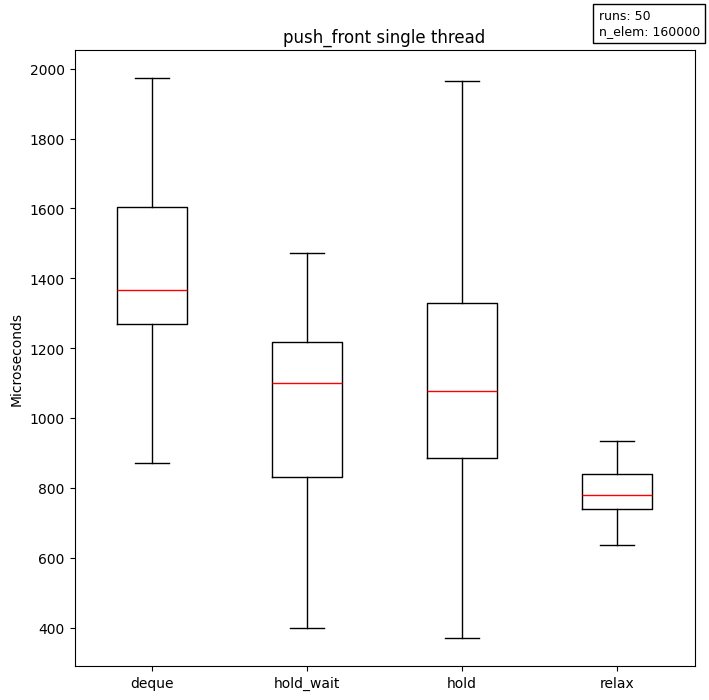

In [71]:
# push_front
# dati test
nomi = ["deque", "hold_wait", "hold", "relax"]
dati_push_front = []
for i in range(4):
    dati_push_front.append(np.genfromtxt("test_"+nomi[i]+"_push_front.txt",delimiter=',',dtype=int)[:-1])
    
n_elem = 160000

plot(dati_push_back,"push_front single thread", nomi)

## multithread

In [3]:
n_thread = [1,2,4,8] #hard code in .sh copialo da li
n_elem = 16000 ##hard code quando fai run di fie.sh

In [4]:
def multi_plot(data1, data2, data3, data4, title, labels, n_threads):
    fig, ax = plt.subplots(figsize=[10, 10])

    boxes = []
    colors = []
    group_positions = []  # Per le etichette centrate

    color_map = ["peachpuff", "orange", "yellow", "blue"]

    for i in range(len(n_threads)):
        boxes.extend([data1[i], data2[i], data3[i], data4[i]])
        colors.extend(color_map)
        # Ogni gruppo di 4 box parte alla posizione 4*i+1 → il centro è +1.5
        group_center = 4 * i + 2.5
        group_positions.append(group_center)

    # Crea boxplot
    bplot = ax.boxplot(boxes, showfliers=False, patch_artist=True)

    # Colori per ogni box
    for patch, color in zip(bplot['boxes'], colors):
        patch.set_facecolor(color)

    # Etichette centrate per ogni gruppo
    ax.set_xticks(group_positions)
    ax.set_xticklabels([str(n) for n in n_threads])

    # Etichette e titolo
    ax.set_ylabel('Microseconds')
    ax.set_xlabel('n_threads')
    ax.set_title(title, loc='left')

    # Legenda (usiamo solo il primo gruppo per i colori)
    legend_handles = [bplot["boxes"][i] for i in range(4)]
    ax.legend(legend_handles, labels, loc='upper right')

    # Mediane in rosso
    for median in bplot['medians']:
        median.set_color('red')

    plt.figtext(0.78, 0.98, f"runs: {len(data1[0])}\nn_elem: {n_elem}", fontsize=9, 
            bbox=dict(facecolor='white', edgecolor='black'))

    plt.tight_layout()
    plt.show()

push front multi

In [106]:
!rm test_*_push_front_multi_*.txt

In [103]:
!./multi.sh push_front 10 1600

In [13]:
#carica dati da .txt
dati_deque_push_front_multi = []
dati_hold_push_front_multi = []
dati_hold_wait_push_front_multi = []
dati_relax_push_front_multi = []

for i,th in enumerate(n_thread):
    dati_deque_push_front_multi.append(np.genfromtxt("test_deque_push_front_multi_numthread"+str(th)+".txt",delimiter=',',dtype=int)[:-1])
    dati_hold_push_front_multi.append(np.genfromtxt("test_hold_push_front_multi_numthread"+str(th)+".txt",delimiter=',',dtype=int)[:-1])
    dati_hold_wait_push_front_multi.append(np.genfromtxt("test_hold_wait_push_front_multi_numthread"+str(th)+".txt",delimiter=',',dtype=int)[:-1])
    dati_relax_push_front_multi.append(np.genfromtxt("test_relax_push_front_multi_numthread"+str(th)+".txt",delimiter=',',dtype=int)[:-1])

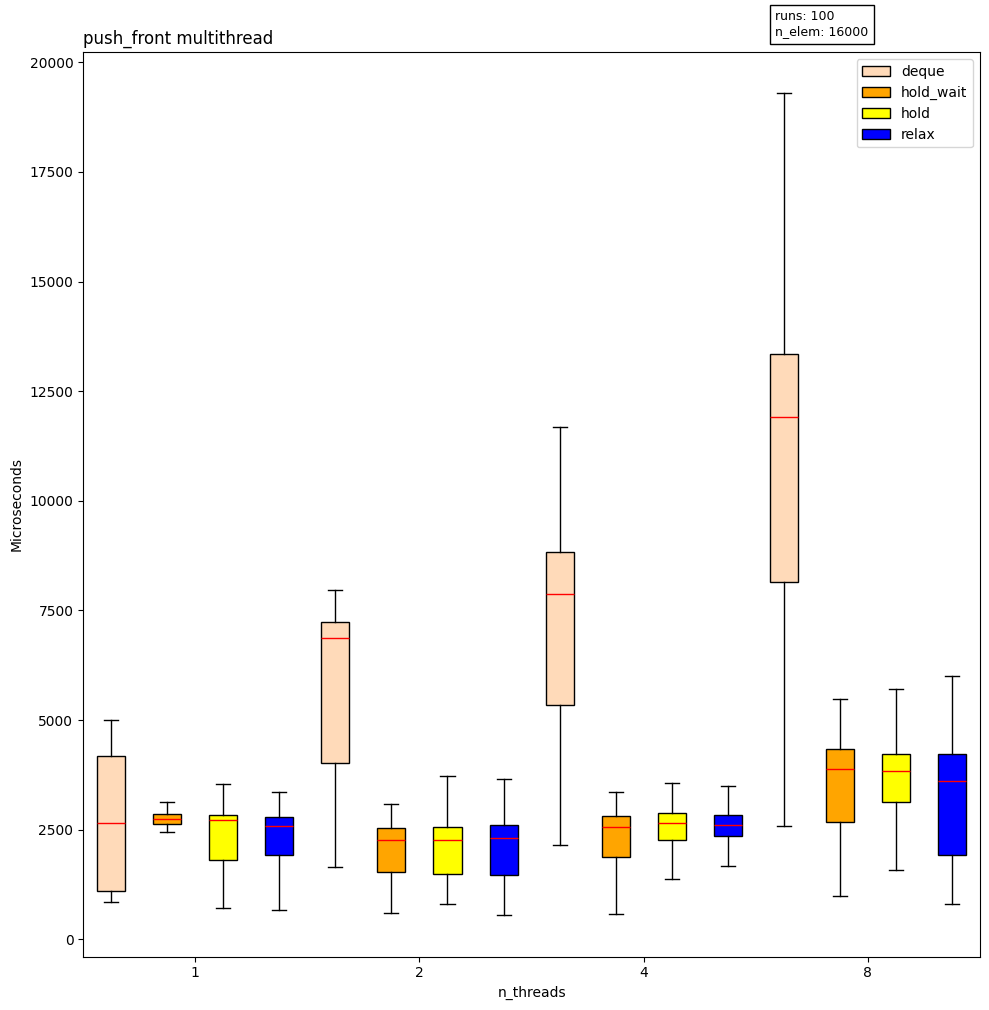

In [14]:
multi_plot(dati_deque_push_front_multi, dati_hold_push_front_multi, dati_hold_wait_push_front_multi,dati_relax_push_front_multi , "push_front multithread", ["deque","hold_wait","hold","relax"], n_thread)

push back multi

In [109]:
!rm test_*_push_back_multi_*.txt

rm: cannot remove 'test_*_push_back_multi_*.txt': No such file or directory


In [ ]:
!./multi.sh push_back 50 1600

In [110]:
#carica dati da .txt
dati_deque_push_back_multi = []
dati_hold_push_back_multi = []
dati_hold_wait_push_back_multi = []
dati_relax_push_back_multi = []

for i,th in enumerate(n_thread):
    dati_deque_push_back_multi.append(np.genfromtxt("test_deque_push_back_multi_numthread"+str(th)+".txt",delimiter=',',dtype=int)[:-1])
    dati_hold_push_back_multi.append(np.genfromtxt("test_hold_push_back_multi_numthread"+str(th)+".txt",delimiter=',',dtype=int)[:-1])
    dati_hold_wait_push_back_multi.append(np.genfromtxt("test_hold_wait_push_back_multi_numthread"+str(th)+".txt",delimiter=',',dtype=int)[:-1])
    dati_relax_push_back_multi.append(np.genfromtxt("test_relax_push_back_multi_numthread"+str(th)+".txt",delimiter=',',dtype=int)[:-1])

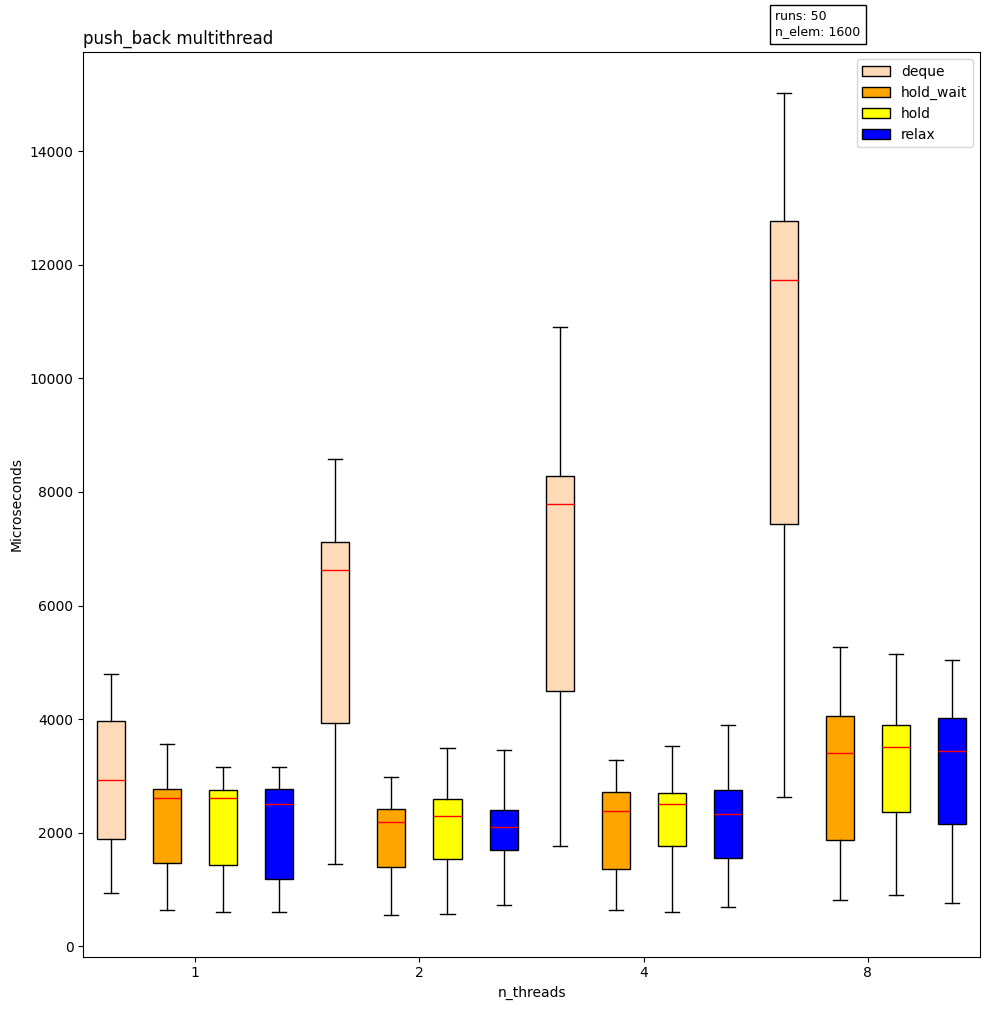

In [111]:
multi_plot(dati_deque_push_back_multi, dati_hold_push_back_multi, dati_hold_wait_push_back_multi,dati_relax_push_back_multi , "push_back multithread", ["deque","hold_wait","hold","relax"], n_thread)

pop back

In [112]:
!rm test_*_pop_back_multi_*.txt

In [ ]:
!./multi.sh pop_back 50 1600

In [113]:
#carica dati da .txt
dati_deque_pop_back_multi = []
dati_hold_pop_back_multi = []
dati_hold_wait_pop_back_multi = []
dati_relax_pop_back_multi = []

for i,th in enumerate(n_thread):
    dati_deque_pop_back_multi.append(np.genfromtxt("test_deque_pop_back_multi_numthread"+str(th)+".txt",delimiter=',',dtype=int)[:-1])
    dati_hold_pop_back_multi.append(np.genfromtxt("test_hold_pop_back_multi_numthread"+str(th)+".txt",delimiter=',',dtype=int)[:-1])
    dati_hold_wait_pop_back_multi.append(np.genfromtxt("test_hold_wait_pop_back_multi_numthread"+str(th)+".txt",delimiter=',',dtype=int)[:-1])
    dati_relax_pop_back_multi.append(np.genfromtxt("test_relax_pop_back_multi_numthread"+str(th)+".txt",delimiter=',',dtype=int)[:-1])

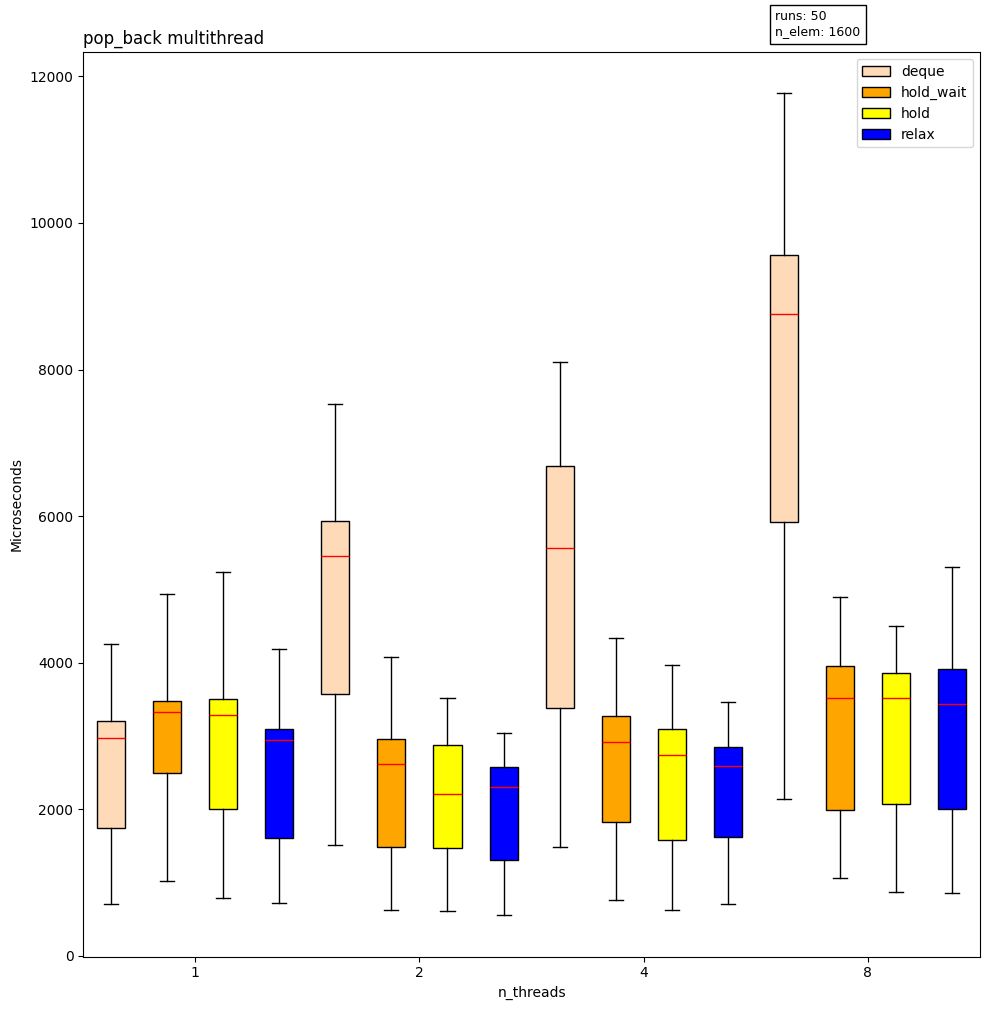

In [114]:
multi_plot(dati_deque_pop_back_multi, dati_hold_pop_back_multi, dati_hold_wait_pop_back_multi,dati_relax_pop_back_multi , "pop_back multithread", ["deque","hold_wait","hold","relax"], n_thread)

pop front multi

In [ ]:
!rm test_*_pop_front_multi_*.txt

In [ ]:
!./multi.sh pop_front 50 1600

In [115]:
#carica dati da .txt
dati_deque_pop_front_multi = []
dati_hold_pop_front_multi = []
dati_hold_wait_pop_front_multi = []
dati_relax_pop_front_multi = []

for i,th in enumerate(n_thread):
    dati_deque_pop_front_multi.append(np.genfromtxt("test_deque_pop_front_multi_numthread"+str(th)+".txt",delimiter=',',dtype=int)[:-1])
    dati_hold_pop_front_multi.append(np.genfromtxt("test_hold_pop_front_multi_numthread"+str(th)+".txt",delimiter=',',dtype=int)[:-1])
    dati_hold_wait_pop_front_multi.append(np.genfromtxt("test_hold_wait_pop_front_multi_numthread"+str(th)+".txt",delimiter=',',dtype=int)[:-1])
    dati_relax_pop_front_multi.append(np.genfromtxt("test_relax_pop_front_multi_numthread"+str(th)+".txt",delimiter=',',dtype=int)[:-1])

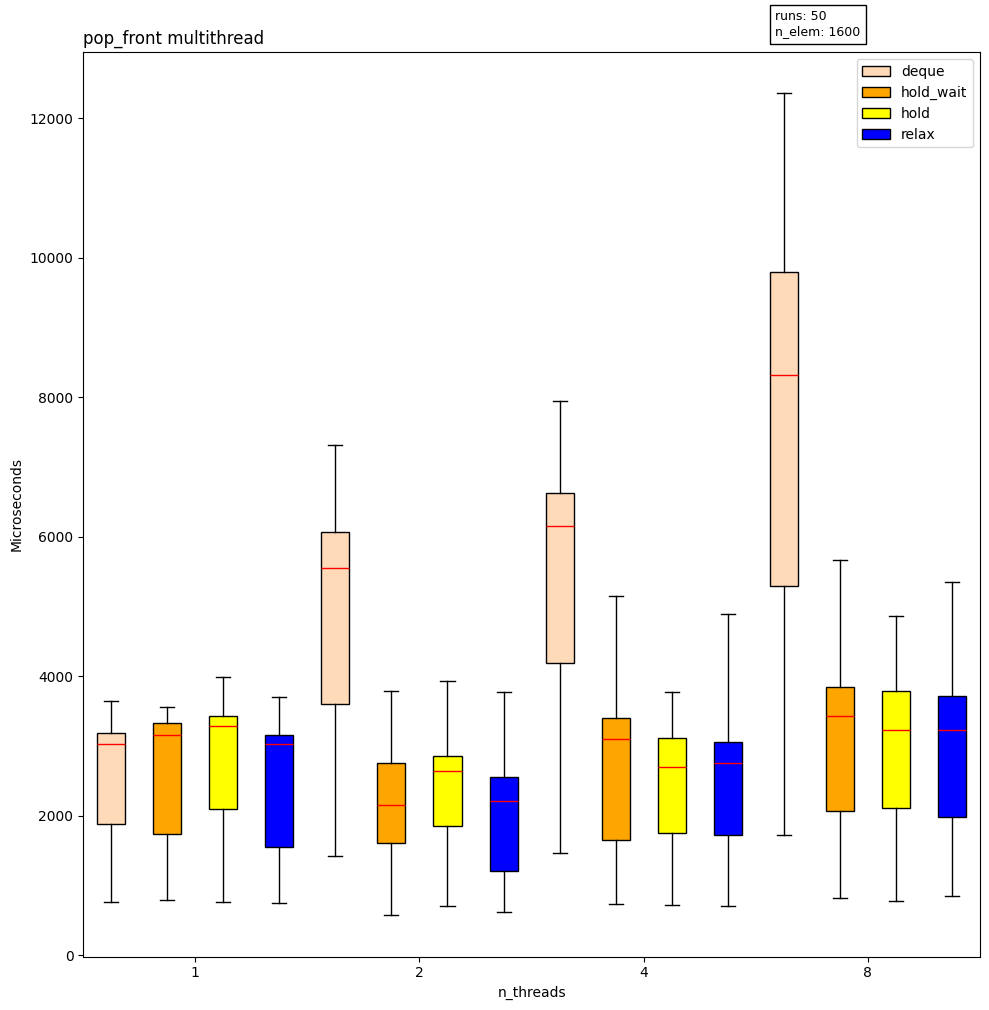

In [116]:
multi_plot(dati_deque_pop_front_multi, dati_hold_pop_front_multi, dati_hold_wait_pop_front_multi,dati_relax_pop_front_multi , "pop_front multithread", ["deque","hold_wait","hold","relax"], n_thread)

## Random

In [123]:
!rm test_*_pop_push_rand_*.txt

In [ ]:
!./random.sh 50 1600

In [124]:
#carica dati da .txt
dati_deque_random = []
dati_hold_random = []
dati_hold_wait_random = []
dati_relax_random = []

for i,th in enumerate(n_thread):
    dati_deque_random.append(np.genfromtxt("test_deque_pop_push_rand_numthread"+str(th)+".txt",delimiter=',',dtype=int)[:-1])
    dati_hold_random.append(np.genfromtxt("test_hold_pop_push_rand_numthread"+str(th)+".txt",delimiter=',',dtype=int)[:-1])
    dati_hold_wait_random.append(np.genfromtxt("test_hold_wait_pop_push_rand_numthread"+str(th)+".txt",delimiter=',',dtype=int)[:-1])
    dati_relax_random.append(np.genfromtxt("test_relax_pop_push_rand_numthread"+str(th)+".txt",delimiter=',',dtype=int)[:-1])

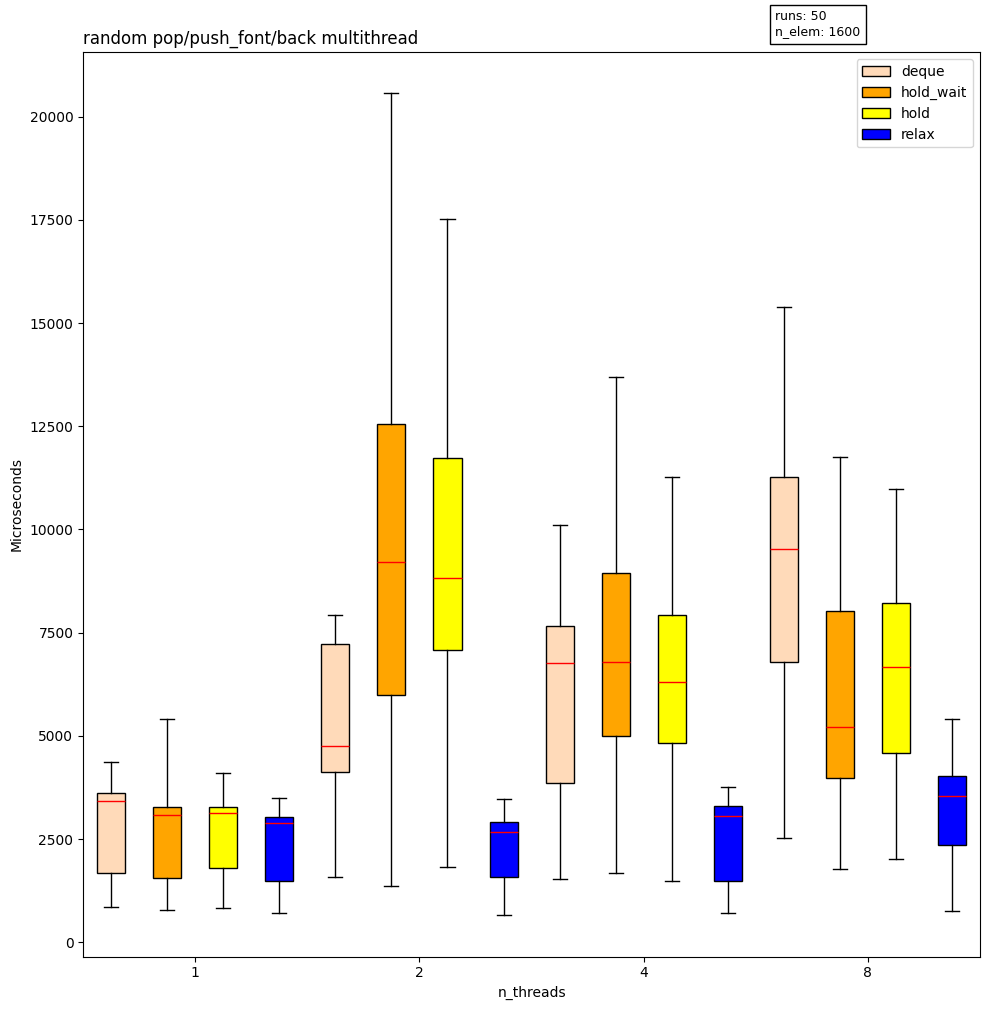

In [125]:
multi_plot(dati_deque_random, dati_hold_random, dati_hold_wait_random,dati_relax_random , "random pop/push_font/back multithread", ["deque","hold_wait","hold","relax"], n_thread)

## accuracy di relax

In [172]:
n_thread = [1,2,4,8]
n_elem = 100000

In [184]:
!rm test_relax_random_accuracy*.txt

In [158]:
!./test_relax_random_accuracy 16000 4 ## quanti random pop/push a buon fine:

13059,

In [193]:
!./accuracy_relax.sh 40 100000

In [194]:
#carica dati da .txt
dati_accuracy_relax = []

for i,th in enumerate(n_thread):
    dati_accuracy_relax.append(np.genfromtxt("test_relax_random_accuracy_numthread"+str(th)+".txt",delimiter=',',dtype=int)[:-1])
    dati_accuracy_relax[i] = dati_accuracy_relax[i] / n_elem

In [197]:
def plot(data_list, title, labels):

    fig, ax = plt.subplots(figsize=[8, 8])

    boxes = []
    ticks = []

    for i in range(0,len(data_list)):
        boxes.append(data_list[i])
        ticks.append(labels[i])

    bplot = ax.boxplot(boxes, showfliers=False)
    # Etichette per gli assi
    ax.set_xticks(range(1,len(labels)+1),ticks)
    ax.set(ylabel = '%')
    ax.set(xlabel = 'n_thread')
    ax.set(title = title)

    for median in bplot['medians']:
        median.set_color('red')
    plt.figtext(0.78, 0.9, f"runs: {len(data_list[0])}\nn_elem: {n_elem}", fontsize=9, 
            bbox=dict(facecolor='white', edgecolor='black'))
    plt.show()

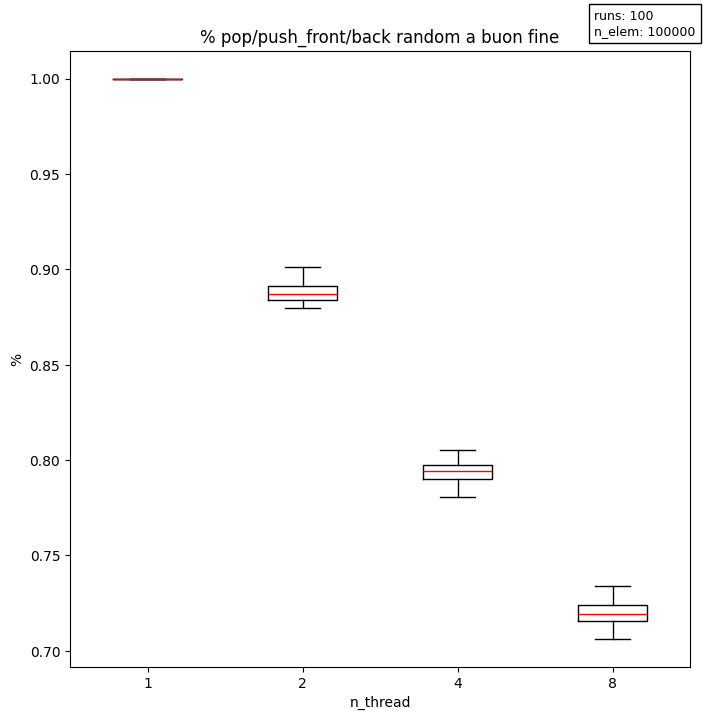

In [198]:
plot(dati_accuracy_relax, "% pop/push_front/back random a buon fine",n_thread)